In [1]:
import pandas as pd, numpy as np
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import get_scorer
from joblib import Parallel, delayed
from scipy.stats import wilcoxon
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
# ----------------------------------------------------
# Coloring (violin/survival)
DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

# ----------------------------------------------------
# Core utilities (giữ logic notebook)
def addColumns(data):
    responderCrit = data['BR'].isin(['CR','PR'])
    progressorCrit = data['BR'].isin(['PD'])
    data["PD_Responders"] = "SD/MR"
    data.loc[responderCrit,"PD_Responders"] = 'Responder'
    data.loc[progressorCrit,"PD_Responders"] = 'Progressor'
    data["PD_nonPD"] = 0
    data.loc[progressorCrit, "PD_nonPD"] = 1
    import math
    for col in ["nonsyn_muts","clonal_muts","subclonal_muts","total_neoantigens"]:
        data[f"log_{col}"] = [math.log((x if x>=0 else 0)+1e-9,10) for x in data[col]]
    return data

def GenRegDF(df, categVars, quantVars, outcome=None):
    if outcome is not None:
        regDF = df[df[outcome].apply(np.isreal) & ~df[outcome].isnull()][[outcome]+quantVars]
    else:
        regDF = df[quantVars]
    nullQuants = []
    for q in quantVars:
        regDF.loc[:, q] = pd.to_numeric(regDF[q], errors='coerce')
        if regDF[q].isnull().sum()>0: nullQuants.append(q)
        med = regDF[q].median()
        regDF[q+"_upper"] = (regDF[q] > med).astype(int)
        regDF[q+"_lower"] = (regDF[q] <= med).astype(int)
    for c in categVars:
        dummies = pd.get_dummies(df[c], prefix=c)
        regDF = regDF.merge(dummies.iloc[:,1:], left_index=True, right_index=True)
    scaler = MinMaxScaler((0,1))
    good = [c for c in regDF.columns if c not in nullQuants]
    temp = pd.DataFrame(scaler.fit_transform(regDF[good]), index=regDF.index, columns=good)
    temp[nullQuants] = regDF[nullQuants]
    regDF = temp
    regDF["intercept"] = 1
    return regDF

def _statistical_test(a,b):
    diff = np.array(a)-np.array(b)
    if np.all(diff==0): return 1.0
    _, p = wilcoxon(a,b,alternative="two-sided")
    return p

def compare_cross_validation(
    real,
    synth,
    target_col,
    model,
    cv, 
    metric, 
    n_jobs = -1
) -> dict:

    X_real = real.drop(columns=[target_col])
    y_real = real[target_col]
    X_synth = synth.drop(columns=[target_col])
    y_synth = synth[target_col]

    rkf = cv
    scorer = get_scorer(metric)
    # orig_scores, synth_scores = [], []

    real_folds = list(rkf.split(X_real, y_real))
    synth_folds = list(rkf.split(X_synth, y_synth))
    
    def fit_and_score(real_train_idx, real_test_idx, synth_train_idx):
        X_real_train, X_real_test = (
            X_real.iloc[real_train_idx],
            X_real.iloc[real_test_idx],
        )
        y_real_train, y_real_test = (
            y_real.iloc[real_train_idx],
            y_real.iloc[real_test_idx],
        )

        X_synth_train = X_synth.iloc[synth_train_idx]
        y_synth_train = y_synth.iloc[synth_train_idx]

        # Try to set n_jobs if supported
        # try:
        model_real = clone(model)
        # except ValueError:
            # model_real = clone(self.model)
        model_real.fit(X_real_train, y_real_train)
        orig_score = scorer(model_real, X_real_test, y_real_test)

        # try:
            # model_synth = clone(self.model).set_params(n_jobs=self.n_jobs)
        # except ValueError:
        model_synth = clone(model)
        model_synth.fit(X_synth_train, y_synth_train)
        synth_score = scorer(model_synth, X_real_test, y_real_test)
        return orig_score, synth_score

    results = Parallel(n_jobs=n_jobs)(
        delayed(fit_and_score)(real_train_idx, real_test_idx, synth_train_idx)
        for (real_train_idx, real_test_idx), (synth_train_idx, _) in zip(real_folds, synth_folds)
    )
    orig_scores, synth_scores = zip(*results)

    p_value = _statistical_test(orig_scores, synth_scores)
    is_improved = np.mean(orig_scores) <= np.mean(synth_scores)

    compare_cross_validation_result = {
        "real_scores": orig_scores,
        "synthetic_scores": synth_scores,
        "is_improved": is_improved,
        "p_value": p_value,
    }

    return compare_cross_validation_result
# ----------------------------------------------------
# Chuẩn bị dữ liệu (dataset_dict đã merge ssGSEA)
def build_full_processed(dataset_dict):
    out = {}
    for name, df in dataset_dict.items():
        dfp = addColumns(df.copy())
        dfp["LN_Met"] = dfp["LN_Met"].astype(int)
        out[name] = dfp
    return out

def make_reg_tables(processed):
    fullProcessedData = {}
    for name, fullDF in processed.items():
        quantVars = ['log_nonsyn_muts','heterogeneity','purity','ploidy','Tx_Start_LDH']
        categVars = ['LN_Met']
        postIpi = fullDF[fullDF["daysBiopsyAfterIpiStart"]=="postIpi"].index
        noIpi   = fullDF[fullDF["daysBiopsyAfterIpiStart"]=="noIpi"].index
        prog = list(fullDF[fullDF['PD_Responders']=="Progressor"].index)
        nprog= list(fullDF[fullDF['PD_nonPD']==0].index)
        PDpost = list(set(postIpi)&set(prog)); nPDpost = [x for x in postIpi if x not in prog]
        PDno   = list(set(noIpi)&set(prog));  nPDno   = [x for x in noIpi if x not in prog]

        regDFs = {}
        for outcome, (g1, g0) in {
            "Ipi_Exp": [PDpost, nPDpost],
            "Ipi_Naive": [PDno, nPDno],
        }.items():
            tmp = fullDF.copy()
            tmp.loc[[i for i in g1 if i in tmp.index], 'outcome'] = 1
            tmp.loc[[i for i in g0 if i in tmp.index], 'outcome'] = 0
            tmp = tmp[~tmp['outcome'].isnull()]
            regDFs[outcome] = tmp

        fullRegDFs = {}
        for outcome in ["Ipi_Exp","Ipi_Naive"]:
            regDF = regDFs[outcome]
            tempDF = GenRegDF(fullDF[categVars+quantVars], categVars, quantVars)
            regDF = regDF.merge(tempDF, how='inner', left_index=True, right_index=True)
            regDF = regDF.select_dtypes(include=[np.number])
            
            regDF = regDF.loc[:, regDF.var()!=0]
            regDF['intercept'] = 1
            fullRegDFs[outcome] = regDF
            
        fullProcessedData[name] = fullRegDFs
    return fullProcessedData




def run_classification(
    fullProcessedData,
    case='Ipi_Exp',
    features=['MHC-II','LN_Met_1','Tx_Start_LDH_lower','outcome'],
    metric='roc_auc'
):
    """
    Run classification comparisons (Origin vs each synthetic dataset) and optionally
    perform multiple-testing adjustment on the p-values from compare_cross_validation.

    Params:
        fullProcessedData: dict produced by make_reg_tables(...)
        case: cohort key ('Ipi_Exp' by default)
        features: features to use (must include 'outcome' at end)
        metric: scoring metric name for sklearn.get_scorer
        adjust_pvalues: if True, perform p-value adjustment using statsmodels.multipletests
        adjust_method: multipletests method, e.g. "holm" (we will use this)
        adjust_alpha: familywise alpha passed to multipletests (not strictly required to store pvals)
        adjust_scope: "global" to adjust across all (synth, model) pairs; "per_classifier" to adjust
                      p-values separately within each classifier (model).

    Returns:
        results: nested dict results[synth_name][model_name] includes
                 "real_scores","synthetic_scores","p_value" and if adjusted:
                 "p_value_{method}" e.g. "p_value_holm".
    """
    models = {
        "Logistic_Regression": LogisticRegression(penalty='l2', max_iter=100000,
                                                 random_state=42, solver='lbfgs', n_jobs=-1),
        'RF': RandomForestClassifier(random_state=42, n_jobs = -1),
        "MLP": MLPClassifier(alpha=0.01, max_iter=10000, validation_fraction=0.1,
                             random_state=42, hidden_layer_sizes=150),
    }
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

    results = {}
    ori = fullProcessedData['Origin'][case][features]
    for synth_name, data_case in fullProcessedData.items():
        if synth_name == 'Origin': continue
        print(synth_name)
        synth = data_case[case][features]
        metric_results_cv = {}
        for model_name, model in models.items():
            mdl = clone(model)
            metric_results_cv[model_name] = compare_cross_validation(
                real=ori, synth=synth, target_col='outcome',
                model=mdl, cv=cv, metric=metric, n_jobs=-1
            )
        results[synth_name] = metric_results_cv
    return results

In [16]:
# -*- coding: utf-8 -*-
from __future__ import annotations

from typing import Dict, Optional, Sequence, Tuple, Any, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATASET_COLORS: Dict[str, str] = {
    "Origin": "#4d4d4d",
    "Avatars K5":  "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN":  "#8da0cb",
    "Gaussian Copula":   "#e78ac3",
    "Synthpop":  "#a6d854",
    "TVAE":  "#ffd92f",
}


def _apply_plot_style():
    """Apply matplotlib styles."""
    try:
        plt.style.use(["science", "nature", "notebook"])
    except Exception:
        pass

    plt.rcParams.update({
        'text.usetex': False,
        'axes.edgecolor': '#333333',
        'xtick.minor.visible': False,
        'ytick.minor.visible': False,
        'xtick.top': False,
        'ytick.right': False,
    })


def plot_logistic_regression_replicates(
    Result_As_Seed: Dict[int, Dict[str, Dict[str, Dict[str, Any]]]],
    synthesizer_names: Sequence[str],
    metric_name: str = "ROC-AUC",
    classifier_name: str = "Logistic_Regression",
    p_value_key: str = "p_value",  # Use unadjusted p-value
    significance_threshold: float = 0.05,
    save_path: Optional[str] = None,
    figsize: Tuple[float, float] = (20, 8),
    all_seeds: Optional[List[int]] = None,  # Expected seeds list
) -> None:
    """
    Plot boxplots for Logistic Regression across all 5 replicates (seeds).
    Each synthesizer will have 5 boxplots (one per seed).
    Mark replicates with asterisk (*) if p-value > significance_threshold (comparable performance).
    Show placeholder boxes for missing seeds (e.g., TVAE seeds 1, 3).

    Args:
        Result_As_Seed: nested dict: Result_As_Seed[seed][synth_name][classifier_name]
        synthesizer_names: list of synthesizer names to plot
        metric_name: y-axis label
        classifier_name: which classifier to extract (default: "Logistic_Regression")
        p_value_key: which p-value to use ("p_value" for unadjusted)
        significance_threshold: p-value threshold (default 0.05)
        save_path: optional path to save figure
        figsize: figure size
        all_seeds: list of all expected seeds (e.g., [0, 1, 2, 3, 42])

    Returns:
        None
    """
    _apply_plot_style()

    if all_seeds is None:
        all_seeds = sorted(Result_As_Seed.keys())
    else:
        all_seeds = sorted(all_seeds)
    
    origin_color = DATASET_COLORS.get("Origin", "#4d4d4d")
    
    # Collect data
    positions: List[float] = []
    data_list: List[List[float]] = []
    colors_list: List[str] = []
    labels_list: List[str] = []
    
    # For annotations
    p_values_list: List[Optional[float]] = []
    is_comparable_list: List[bool] = []
    is_missing_list: List[bool] = []  # Track missing data
    
    start_x = 0.0
    group_centers: List[float] = []
    group_labels: List[str] = []
    group_bounds: List[Tuple[float, float]] = []
    
    # First, add Origin (aggregate all seeds)
    origin_data_all = []
    for seed in all_seeds:
        if seed not in Result_As_Seed:
            continue
        for synth_name in synthesizer_names:
            if synth_name in Result_As_Seed[seed] and classifier_name in Result_As_Seed[seed][synth_name]:
                real_scores = Result_As_Seed[seed][synth_name][classifier_name].get("real_scores", [])
                if real_scores:
                    origin_data_all.extend([float(v) for v in real_scores])
                    break  # Only need to add once per seed
        
    if origin_data_all:
        positions.append(start_x)
        data_list.append(origin_data_all)
        colors_list.append(origin_color)
        labels_list.append("Origin\n(all seeds)")
        p_values_list.append(None)
        is_comparable_list.append(False)
        is_missing_list.append(False)
        start_x += 1.5  # Extra gap after Origin
    
    # Now add each synthesizer with ALL expected seeds (including missing ones)
    for synth_name in synthesizer_names:
        group_positions = []
        synth_color = DATASET_COLORS.get(synth_name, "#888888")
        
        for seed in all_seeds:
            # Check if data exists for this seed
            has_data = (
                seed in Result_As_Seed and
                synth_name in Result_As_Seed[seed] and
                classifier_name in Result_As_Seed[seed][synth_name]
            )
            
            if has_data:
                result = Result_As_Seed[seed][synth_name][classifier_name]
                synth_scores = result.get("synthetic_scores", [])
                
                if synth_scores:
                    # Normal case: data exists
                    p_val = result.get(p_value_key, None)
                    if p_val is not None:
                        p_val = float(p_val)
                    
                    is_comparable = (p_val is not None) and (p_val > significance_threshold)
                    
                    positions.append(start_x)
                    data_list.append([float(v) for v in synth_scores])
                    colors_list.append(synth_color)
                    labels_list.append(f"{synth_name}\nSeed {seed}")
                    p_values_list.append(p_val)
                    is_comparable_list.append(is_comparable)
                    is_missing_list.append(False)
                    group_positions.append(start_x)
                    
                    start_x += 1.0
                    continue
            
            # Missing data: create placeholder
            positions.append(start_x)
            data_list.append([0.0])  # Placeholder value
            colors_list.append("#e0e0e0")  # Gray color for missing
            labels_list.append(f"{synth_name}\nSeed {seed}")
            p_values_list.append(None)
            is_comparable_list.append(False)
            is_missing_list.append(True)
            group_positions.append(start_x)
            
            start_x += 1.0
        
        if group_positions:
            center = float(np.mean(group_positions))
            group_centers.append(center)
            group_labels.append(synth_name)
            group_bounds.append((min(group_positions), max(group_positions)))
            start_x += 0.8  # Gap between synthesizers
    
    if not data_list:
        raise ValueError("No data found for plotting.")
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    
    flierprops = dict(marker="o", markersize=3, markeredgecolor="#666666", alpha=0.6)
    medianprops = dict(linewidth=1.5, color="black")
    whiskerprops = dict(linewidth=0.9, color="#333333")
    capprops = dict(linewidth=0.9, color="#333333")
    boxprops = dict(linewidth=1.0)
    
    bp = ax.boxplot(
        data_list,
        positions=positions,
        widths=0.7,
        patch_artist=True,
        showfliers=True,
        flierprops=flierprops,
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        boxprops=boxprops,
    )
    
    # Color boxes
    for i, (box, color, is_missing) in enumerate(zip(bp["boxes"], colors_list, is_missing_list)):
        box.set_facecolor(color)
        if is_missing:
            box.set_edgecolor("#999999")
            box.set_linewidth(1.0)
            box.set_linestyle("--")  # Dashed line for missing
            box.set_alpha(0.5)
        else:
            box.set_edgecolor("#222222")
            box.set_linewidth(1.0)
            box.set_alpha(0.85)
    
    # Style whiskers, caps, medians
    for i, (whisk, is_missing) in enumerate(zip(bp.get("whiskers", []), is_missing_list * 2)):  # *2 because 2 whiskers per box
        if i // 2 < len(is_missing_list) and is_missing_list[i // 2]:
            whisk.set_alpha(0.3)
        else:
            whisk.set_color("#222222")
    
    for i, (cap, is_missing) in enumerate(zip(bp.get("caps", []), is_missing_list * 2)):
        if i // 2 < len(is_missing_list) and is_missing_list[i // 2]:
            cap.set_alpha(0.3)
        else:
            cap.set_color("#222222")
    
    for i, (med, is_missing) in enumerate(zip(bp.get("medians", []), is_missing_list)):
        if is_missing:
            med.set_alpha(0.3)
        else:
            med.set_color("black")
            med.set_linewidth(1.6)
    
    # Calculate y-range for positioning (exclude missing data)
    valid_data = [d for d, is_miss in zip(data_list, is_missing_list) if not is_miss]
    if valid_data:
        y_min = min([min(d) for d in valid_data])
        y_max = max([max(d) for d in valid_data])
    else:
        y_min, y_max = 0.0, 1.0
    
    y_range = y_max - y_min if y_max > y_min else 1.0
    y_off_mean = y_range * 0.02
    y_off_star = y_range * 0.06
    
    # Add mean markers and asterisk annotations
    for pos, values, is_comparable, is_missing in zip(positions, data_list, is_comparable_list, is_missing_list):
        if is_missing:
            # Add "N/A" text for missing data
            ax.text(pos, y_min + y_range * 0.5, "N/A", ha="center", va="center",
                    fontsize=10, color="#999999", fontweight="bold", style="italic")
            continue
        
        m = float(np.mean(values))
        
        # Mean marker (simple diamond)
        ax.scatter(
            pos, m,
            facecolor="white",
            edgecolors="#d32f2f",
            marker="D",
            s=60,
            zorder=11,
            linewidths=1.5,
        )
        
        # Mean text
        ax.text(pos, m + y_off_mean, f"{m:.3f}", ha="center", va="bottom", 
                fontsize=8, color="#111111", fontweight="normal")
        
        # Asterisk for comparable replicates
        if is_comparable:
            ax.text(pos, y_max + y_off_star, "*", ha="center", va="bottom",
                    fontsize=20, color="#2e7d32", fontweight="bold")
    
    # Set x-ticks at group centers
    ax.set_xticks([positions[0]] + group_centers)
    ax.set_xticklabels(["Origin"] + [f"$\\mathbf{{{label}}}$" for label in group_labels], 
                       rotation=0, ha="center", fontsize=11)
    
    # Vertical separators
    for lb, ub in group_bounds:
        sep_x = ub + 0.4
        ax.axvline(x=sep_x, color="#bdbdbd", linestyle="--", linewidth=1.0, alpha=0.5)
    
    ax.set_xlabel("Synthesizer (5 replicates each)", fontsize=12, fontweight="bold")
    ax.set_ylabel(metric_name, fontsize=12, fontweight="bold")
    title = f"{metric_name} Distribution: {classifier_name.replace('_', ' ')} Across 5 Seeds"
    ax.set_title(title, fontsize=14, fontweight="bold")
    
    # Legend
    import matplotlib.patches as mpatches
    from matplotlib.lines import Line2D
    
    origin_patch = mpatches.Patch(color=origin_color, label="Origin (Real)", alpha=0.85)
    
    star_proxy = Line2D([0], [0], marker='*', color='w', 
                        markerfacecolor='#2e7d32', markersize=15,
                        label=f'* Comparable (p > {significance_threshold})', linestyle='None')
    
    missing_patch = mpatches.Patch(facecolor='#e0e0e0', edgecolor='#999999', 
                                   linestyle='--', linewidth=1.0,
                                   label='N/A (Missing data)', alpha=0.5)
    
    ax.legend(handles=[origin_patch, star_proxy, missing_patch], 
             loc="upper right", frameon=True, fontsize=10, fancybox=True, shadow=True)
    
    # Adjust y-axis to make room for asterisks
    ax.set_ylim(y_min - y_range * 0.05, y_max + y_range * 0.15)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✅ Saved: {save_path}")
    
    plt.show()
    plt.close()


def create_summary_table(
    Result_As_Seed: Dict[int, Dict[str, Dict[str, Dict[str, Any]]]],
    synthesizer_names: Sequence[str],
    classifier_name: str = "Logistic_Regression",
    p_value_key: str = "p_value",
    significance_threshold: float = 0.05,
    all_seeds: Optional[List[int]] = None,
) -> pd.DataFrame:
    """
    Create a summary table showing p-values and comparability for each synthesizer and seed.
    Includes rows for missing data.
    
    Returns:
        DataFrame with columns: Synthesizer, Seed, Mean_Synthetic, Mean_Real, P_Value, Comparable
    """
    if all_seeds is None:
        all_seeds = sorted(Result_As_Seed.keys())
    else:
        all_seeds = sorted(all_seeds)
    
    records = []
    
    for synth_name in synthesizer_names:
        for seed in all_seeds:
            # Check if data exists
            has_data = (
                seed in Result_As_Seed and
                synth_name in Result_As_Seed[seed] and
                classifier_name in Result_As_Seed[seed][synth_name]
            )
            
            if not has_data:
                # Missing data
                records.append({
                    "Synthesizer": synth_name,
                    "Seed": seed,
                    "Mean_Synthetic": np.nan,
                    "Mean_Real": np.nan,
                    "P_Value": np.nan,
                    "Comparable": "N/A",
                })
                continue
            
            result = Result_As_Seed[seed][synth_name][classifier_name]
            synth_scores = result.get("synthetic_scores", [])
            real_scores = result.get("real_scores", [])
            
            if not synth_scores or not real_scores:
                records.append({
                    "Synthesizer": synth_name,
                    "Seed": seed,
                    "Mean_Synthetic": np.nan,
                    "Mean_Real": np.nan,
                    "P_Value": np.nan,
                    "Comparable": "N/A",
                })
                continue
            
            p_val = result.get(p_value_key, None)
            if p_val is not None:
                p_val = float(p_val)
            
            mean_synth = float(np.mean(synth_scores))
            mean_real = float(np.mean(real_scores))
            is_comparable = (p_val is not None) and (p_val > significance_threshold)
            
            records.append({
                "Synthesizer": synth_name,
                "Seed": seed,
                "Mean_Synthetic": mean_synth,
                "Mean_Real": mean_real,
                "P_Value": p_val if p_val is not None else np.nan,
                "Comparable": "✓" if is_comparable else "✗",
            })
    
    df = pd.DataFrame(records)
    return df


def calculate_effect_size(real_scores: Sequence[float], synth_scores: Sequence[float]) -> float:
    """
    Calculate Cohen's d effect size.
    
    Interpretation:
    - |d| < 0.2: negligible
    - |d| ~ 0.5: medium
    - |d| > 0.8: large
    
    Returns:
        Cohen's d value
    """
    mean_diff = np.mean(synth_scores) - np.mean(real_scores)
    pooled_std = np.sqrt((np.var(real_scores, ddof=1) + np.var(synth_scores, ddof=1)) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0.0
    return cohens_d


def create_summary_table_with_effect_size(
    Result_As_Seed: Dict[int, Dict[str, Dict[str, Dict[str, Any]]]],
    synthesizer_names: Sequence[str],
    classifier_name: str = "Logistic_Regression",
    p_value_key: str = "p_value",
    significance_threshold: float = 0.05,
    all_seeds: Optional[List[int]] = None,
) -> pd.DataFrame:
    """
    Create enhanced summary table with effect sizes and interpretation.
    Includes rows for missing data.
    
    Returns:
        DataFrame with columns: Synthesizer, Seed, Mean_Synthetic, Mean_Real, 
                                Difference, P_Value, Effect_Size, Interpretation
    """
    if all_seeds is None:
        all_seeds = sorted(Result_As_Seed.keys())
    else:
        all_seeds = sorted(all_seeds)
    
    records = []
    
    for synth_name in synthesizer_names:
        for seed in all_seeds:
            # Check if data exists
            has_data = (
                seed in Result_As_Seed and
                synth_name in Result_As_Seed[seed] and
                classifier_name in Result_As_Seed[seed][synth_name]
            )
            
            if not has_data:
                # Missing data
                records.append({
                    "Synthesizer": synth_name,
                    "Seed": seed,
                    "Mean_Synthetic": np.nan,
                    "Mean_Real": np.nan,
                    "Difference": np.nan,
                    "P_Value": np.nan,
                    "Effect_Size": np.nan,
                    "Interpretation": "N/A (Missing)",
                })
                continue
            
            result = Result_As_Seed[seed][synth_name][classifier_name]
            synth_scores = result.get("synthetic_scores", [])
            real_scores = result.get("real_scores", [])
            
            if not synth_scores or not real_scores:
                records.append({
                    "Synthesizer": synth_name,
                    "Seed": seed,
                    "Mean_Synthetic": np.nan,
                    "Mean_Real": np.nan,
                    "Difference": np.nan,
                    "P_Value": np.nan,
                    "Effect_Size": np.nan,
                    "Interpretation": "N/A (Missing)",
                })
                continue
            
            p_val = result.get(p_value_key, None)
            if p_val is not None:
                p_val = float(p_val)
            
            mean_synth = float(np.mean(synth_scores))
            mean_real = float(np.mean(real_scores))
            difference = mean_synth - mean_real
            
            effect_size = calculate_effect_size(real_scores, synth_scores)
            
            # Interpretation
            if p_val is None:
                interpretation = "N/A"
            elif p_val > significance_threshold:
                interpretation = "✓ Comparable"
            elif abs(effect_size) < 0.2:
                interpretation = "⚠ Stat. diff. but negligible"
            else:
                interpretation = "✗ Meaningful difference"
            
            records.append({
                "Synthesizer": synth_name,
                "Seed": seed,
                "Mean_Synthetic": round(mean_synth, 4),
                "Mean_Real": round(mean_real, 4),
                "Difference": round(difference, 4),
                "P_Value": round(p_val, 4) if p_val is not None else np.nan,
                "Effect_Size": round(effect_size, 3),
                "Interpretation": interpretation,
            })
    
    df = pd.DataFrame(records)
    return df

In [11]:
seeds = [0,1,2,3,42]
Result_As_Seed = {}
for seed in seeds:
    if seed == 1 or seed == 3:
        names = ['Origin','Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop']
        datasets = ['original_data', f'avatarsk5_{seed}', f'avatarsk10_{seed}', f'ctgan_{seed}', f'gaussiancopula_{seed}', f'synthpop_{seed}']
    else:
        names = ['Origin','Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']
        datasets = ['original_data', f'avatarsk5_{seed}', f'avatarsk10_{seed}', f'ctgan_{seed}', f'gaussiancopula_{seed}', f'synthpop_{seed}',f'tvae_{seed}']
    try:
            
        dataset_dict = {}
        
        for i, dataset in enumerate(datasets):
            data = pd.read_csv(f'../Melanoma/Data/{dataset}.csv', index_col = 0)
            ssgsea = pd.read_csv(f'../Melanoma/NarrowUtility/ssGSEA/MHC/{dataset}.csv', index_col = 0)
        
            df_merged = pd.concat([data, ssgsea], axis = 1)
            dataset_dict[names[i]]=df_merged
        
        processed = build_full_processed(dataset_dict)
        fullProcessedData = make_reg_tables(processed)
        
        # Classification with Holm-adjusted p-values
        metric_results = run_classification(
            fullProcessedData,
            adjust_pvalues=True,
            adjust_method="holm",
            adjust_scope="per_classifier"  # or "global"
        )
        
        Result_As_Seed[seed] = metric_results
    except Exception as err:
        print(f"{seed}: {err}")



Avatars K5
Avatars K10
CTGAN
Gaussian Copula
Synthpop


/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least

TVAE
Avatars K5
Avatars K10
CTGAN
Gaussian Copula
Synthpop
Avatars K5
Avatars K10
CTGAN
Gaussian Copula
Synthpop
TVAE
Avatars K5
Avatars K10
CTGAN
Gaussian Copula
Synthpop
Avatars K5
Avatars K10
CTGAN
Gaussian Copula
Synthpop
TVAE


✅ Saved: BoxplotPerformance/logistic_regression_replicates.pdf


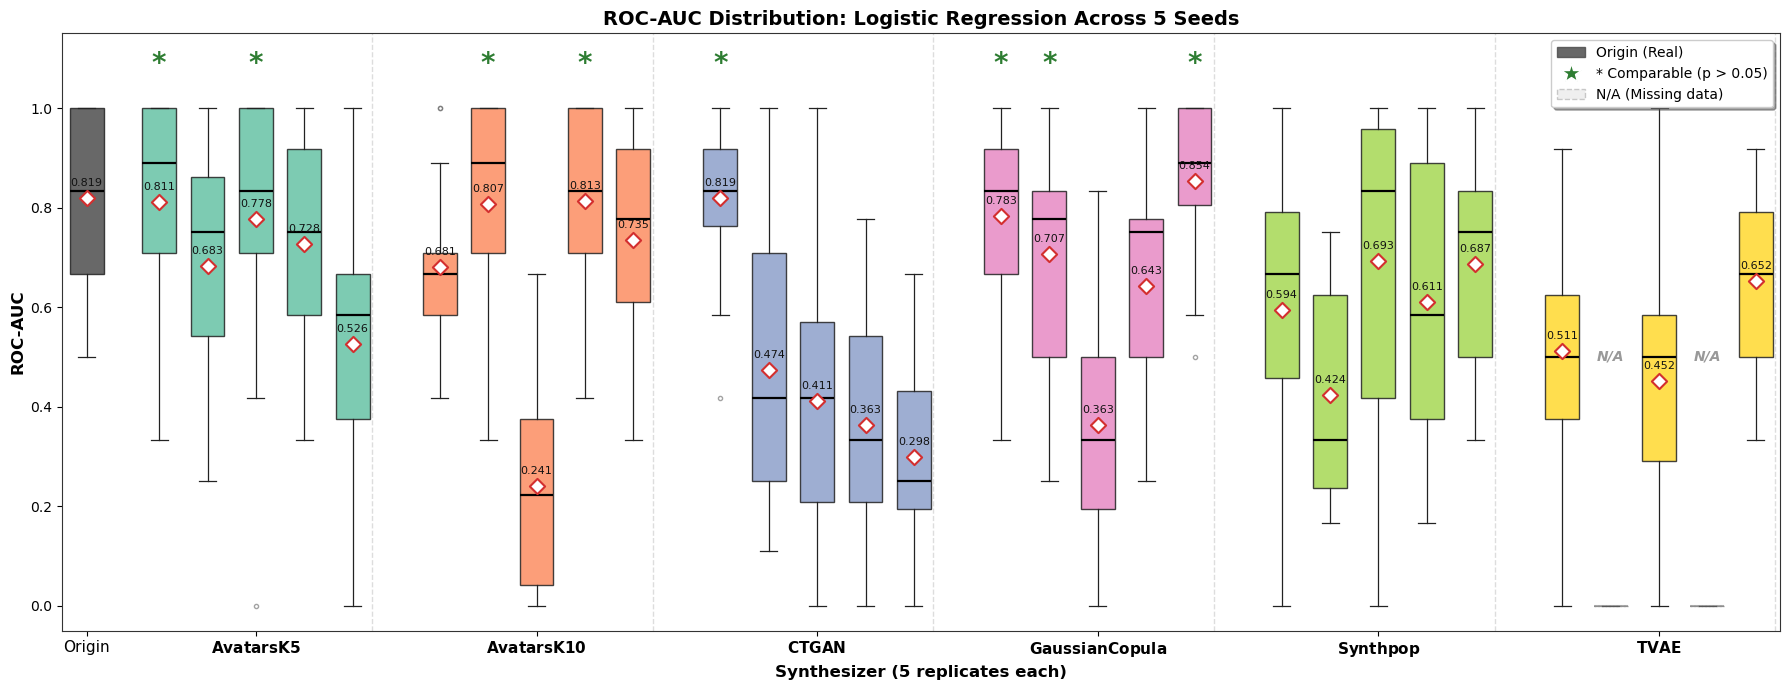


=== Summary Table with Missing Seeds ===
    Synthesizer  Seed  Mean_Synthetic  Mean_Real  Difference  P_Value  Effect_Size          Interpretation
     Avatars K5     0          0.8111     0.8185     -0.0074   0.5913       -0.038            ✓ Comparable
     Avatars K5     1          0.6833     0.8185     -0.1352   0.0410       -0.647 ✗ Meaningful difference
     Avatars K5     2          0.7778     0.8185     -0.0407   0.8109       -0.179            ✓ Comparable
     Avatars K5     3          0.7278     0.8185     -0.0907   0.0232       -0.447 ✗ Meaningful difference
     Avatars K5    42          0.5259     0.8185     -0.2926   0.0107       -1.245 ✗ Meaningful difference
    Avatars K10     0          0.6815     0.8185     -0.1370   0.0183       -0.803 ✗ Meaningful difference
    Avatars K10     1          0.8074     0.8185     -0.0111   0.5616       -0.055            ✓ Comparable
    Avatars K10     2          0.2407     0.8185     -0.5778   0.0002       -3.061 ✗ Meaningful differ

In [18]:
# Specify all expected seeds (including those missing for TVAE)
all_seeds = [0, 1, 2, 3, 42]
synthesizer_names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']

# Plot with placeholders for missing seeds
plot_logistic_regression_replicates(
    Result_As_Seed=Result_As_Seed,
    synthesizer_names=synthesizer_names,
    metric_name="ROC-AUC",
    classifier_name="Logistic_Regression",
    p_value_key="p_value",
    significance_threshold=0.05,
    save_path="BoxplotPerformance/logistic_regression_replicates.pdf",
    figsize=(18, 7),
    all_seeds=all_seeds  # ← Important: specify all expected seeds
)

# Create summary table (will show N/A for missing seeds)
summary_df = create_summary_table_with_effect_size(
    Result_As_Seed=Result_As_Seed,
    synthesizer_names=synthesizer_names,
    classifier_name="Logistic_Regression",
    p_value_key="p_value",
    significance_threshold=0.05,
    all_seeds=all_seeds  # ← Important: specify all expected seeds
)

print("\n=== Summary Table with Missing Seeds ===")
print(summary_df.to_string(index=False))

summary_df.to_csv("BoxplotPerformance/logistic_regression_summary_complete.csv", index=False)
print("✅ Complete summary saved!")

In [29]:
from collections import defaultdict

def collect_logistic_coefs_cv(
    df,
    features,
    target='outcome',
    cv=None,
    random_state=42
):
    X = df.drop(columns=[target])
    y = df[target]

    if cv is None:
        cv = RepeatedStratifiedKFold(
            n_splits=5,
            n_repeats=3,
            random_state=random_state
        )

    rows = []

    for fold_id, (train_idx, _) in enumerate(cv.split(X, y)):
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]

        model = LogisticRegression(
            penalty='l2',
            max_iter=100000,
            solver='lbfgs'
        )
        model.fit(X_train, y_train)

        for feat, coef in zip(X.columns, model.coef_[0]):
            rows.append({
                'feature': feat,
                'coef': coef,
                'fold': fold_id
            })

    return pd.DataFrame(rows)

def collect_all_datasets_coefs(
    fullProcessedData,
    case,
    features,
    seed
):
    coef_all = []

    for name, data_case in fullProcessedData.items():
        df = data_case[case][features]

        coef_df = collect_logistic_coefs_cv(
            df,
            features,
            target='outcome',
            random_state=seed
        )
        coef_df['dataset'] = name
        coef_df['seed'] = seed

        coef_all.append(coef_df)

    return pd.concat(coef_all, axis=0)

In [57]:
# -*- coding: utf-8 -*-
from __future__ import annotations

from typing import Dict, List, Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATASET_COLORS: Dict[str, str] = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}


def _apply_plot_style():
    """Apply matplotlib styles."""
    try:
        plt.style.use(["science", "nature", "notebook"])
    except Exception:
        pass

    plt.rcParams.update({
        'text.usetex': False,
        'axes.edgecolor': '#333333',
        'xtick.minor.visible': False,
        'ytick.minor.visible': False,
        'xtick.top': False,
        'ytick.right': False,
    })


def compute_mean_coefs_per_seed(
    coef_by_seed: Dict[int, pd.DataFrame],
    features: List[str],
    all_seeds: Optional[List[int]] = None,
) -> pd.DataFrame:
    """
    Compute mean coefficient across CV folds for each (dataset, seed, feature).
    
    Args:
        coef_by_seed: dict mapping seed -> DataFrame with columns 
                      ['feature', 'coef', 'fold', 'dataset', 'seed']
        features: list of features to include
        all_seeds: list of all expected seeds (for handling missing data)
    
    Returns:
        DataFrame with columns: ['dataset', 'seed', 'feature', 'mean_coef']
    """
    if all_seeds is None:
        all_seeds = sorted(coef_by_seed.keys())
    
    records = []
    
    # Get all unique datasets from first available seed
    all_datasets = []
    for seed in all_seeds:
        if seed in coef_by_seed:
            all_datasets = list(coef_by_seed[seed]['dataset'].unique())
            break
    
    for seed in all_seeds:
        if seed not in coef_by_seed:
            # Missing seed: add NaN entries
            for dataset in all_datasets:
                for feature in features:
                    records.append({
                        'dataset': dataset,
                        'seed': seed,
                        'feature': feature,
                        'mean_coef': np.nan,
                    })
            continue
        
        coef_df = coef_by_seed[seed].copy()
        
        # Filter by features of interest
        coef_df = coef_df[coef_df['feature'].isin(features)]
        
        # Compute mean across folds for each (dataset, feature)
        grouped = coef_df.groupby(['dataset', 'feature'], as_index=False)['coef'].mean()
        grouped.columns = ['dataset', 'feature', 'mean_coef']
        grouped['seed'] = seed
        
        for _, row in grouped.iterrows():
            records.append({
                'dataset': row['dataset'],
                'seed': seed,
                'feature': row['feature'],
                'mean_coef': row['mean_coef'],
            })
    
    df = pd.DataFrame(records)
    return df


def plot_coef_stripplot_3features(
    coef_by_seed: Dict[int, pd.DataFrame],
    features: List[str],
    all_seeds: Optional[List[int]] = None,
    synthesizer_order: Optional[List[str]] = None,
    save_path: Optional[str] = None,
    figsize: tuple = (14, 10),
) -> None:
    """
    Plot stripplot showing mean coefficients across 5 replicates for each synthetic dataset.
    Origin shows only 1 dot (mean across all seeds and folds).
    Layout: 3 rows (one per feature) × 1 column.
    X-axis: datasets, Y-axis: coefficient values
    
    Args:
        coef_by_seed: dict mapping seed -> coefficient DataFrame
        features: list of 3 features to plot (e.g., ['MHC-II', 'LN_Met_1', 'Tx_Start_LDH_lower'])
        all_seeds: list of all expected seeds (e.g., [0, 1, 2, 3, 42])
        synthesizer_order: order of synthetic datasets on x-axis (Origin always first)
        save_path: optional path to save figure
        figsize: figure size (width, height)
    """
    _apply_plot_style()
    
    if all_seeds is None:
        all_seeds = sorted(coef_by_seed.keys())
    
    if synthesizer_order is None:
        synthesizer_order = ['Avatars K5', 'Avatars K10', 'CTGAN', 
                            'Gaussian Copula', 'Synthpop', 'TVAE']
    
    # Compute mean coefficients per seed
    mean_coef_df = compute_mean_coefs_per_seed(coef_by_seed, features, all_seeds)
    
    # Create subplots: 3 rows × 1 column
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    
    if len(features) != 3:
        raise ValueError("This function expects exactly 3 features for 3-row layout.")
    
    # X-axis labels: Origin first, then synthesizers
    x_labels = ['Origin'] + synthesizer_order
    
    for i, feature in enumerate(features):
        ax = axes[i]
        
        # Filter data for this feature
        feature_df = mean_coef_df[mean_coef_df['feature'] == feature].copy()
        
        if feature_df.empty:
            print(f"⚠️  No data found for feature: {feature}")
            continue
        
        # Separate Origin and synthetic data
        origin_df = feature_df[feature_df['dataset'] == 'Origin']
        synth_df = feature_df[feature_df['dataset'] != 'Origin']
        
        # Plot Origin (single circle dot at x=0: grand mean across all seeds)
        if not origin_df.empty:
            origin_grand_mean = origin_df['mean_coef'].mean()
            color = DATASET_COLORS.get('Origin', "#4d4d4d")
            
            ax.scatter(
                0,  # x position
                origin_grand_mean,
                color=color,
                s=100,
                alpha=0.8,
                edgecolors='black',
                linewidths=1.0,
                marker='o',  # Circle marker like others
                zorder=4,
            )
        
        # Plot synthetic datasets (multiple dots per dataset, one per seed)
        for dataset_idx, dataset in enumerate(synthesizer_order):
            x_idx = dataset_idx + 1  # +1 because Origin is at 0
            
            dataset_df = synth_df[synth_df['dataset'] == dataset]
            
            if dataset_df.empty:
                continue
            
            # Remove NaN values for plotting
            dataset_df_valid = dataset_df.dropna(subset=['mean_coef'])
            
            color = DATASET_COLORS.get(dataset, "#888888")
            
            # Add jitter to x position for better visibility
            n_points = len(dataset_df_valid)
            if n_points > 0:
                jitter = np.random.normal(0, 0.08, n_points)
                x_positions = x_idx + jitter
                
                # Plot points (circles)
                ax.scatter(
                    x_positions,
                    dataset_df_valid['mean_coef'],
                    color=color,
                    s=80,
                    alpha=0.7,
                    edgecolors='black',
                    linewidths=0.5,
                    marker='o',
                    zorder=3,
                )
            
            # Mark missing data (NaN) with 'X' at y=0
            dataset_df_missing = dataset_df[dataset_df['mean_coef'].isna()]
            if not dataset_df_missing.empty:
                ax.scatter(
                    [x_idx] * len(dataset_df_missing),
                    [0] * len(dataset_df_missing),
                    marker='X',
                    color='#999999',
                    s=150,
                    linewidths=2,
                    zorder=2,
                    alpha=0.6,
                )
        
        # Draw zero line (RED dashed)
        ax.axhline(0, color='#d32f2f', linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)
        
        # Styling
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(
            [f"$\\mathbf{{{label}}}$" for label in x_labels], 
            rotation=45, 
            ha='center',
            fontsize=10
        )
        
        ax.set_ylabel('Coefficient', fontsize=11, fontweight='bold')
        ax.set_title(f'{feature}', fontsize=12, fontweight='bold', pad=10)
        
        # Grid
        ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=0.5)
        ax.set_axisbelow(True)
        
        # Add vertical separators between datasets (light gray)
        for x_pos in range(len(x_labels) - 1):
            ax.axvline(x_pos + 0.5, color='#e0e0e0', linestyle='-', linewidth=0.8, alpha=0.5, zorder=0)
        
        # Set x limits with padding
        ax.set_xlim(-0.5, len(x_labels) - 0.5)
    
    # Overall title
    fig.suptitle(
        'Logistic Regression Coefficients Across 5 Replicates',
        fontsize=14,
        fontweight='bold',
        y=0.995
    )
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Saved: {save_path}")
    
    plt.show()
    plt.close()



def create_coef_summary_table(
    coef_by_seed: Dict[int, pd.DataFrame],
    features: List[str],
    all_seeds: Optional[List[int]] = None,
) -> pd.DataFrame:
    """
    Create summary table of coefficients with mean, std, and CV across seeds.
    
    Returns:
        DataFrame with columns: ['dataset', 'feature', 'mean', 'std', 'cv', 'n_seeds']
    """
    mean_coef_df = compute_mean_coefs_per_seed(coef_by_seed, features, all_seeds)
    
    # Group by dataset and feature
    summary = mean_coef_df.groupby(['dataset', 'feature'], as_index=False)['mean_coef'].agg([
        ('mean', 'mean'),
        ('std', 'std'),
        ('n_seeds', 'count'),
    ])
    summary = summary.reset_index()
    
    # Calculate coefficient of variation (CV)
    summary['cv'] = summary['std'] / np.abs(summary['mean'])
    
    # Round for readability
    summary['mean'] = summary['mean'].round(4)
    summary['std'] = summary['std'].round(4)
    summary['cv'] = summary['cv'].round(3)
    
    return summary

In [55]:
# Define features and seeds
FEATURES_TO_PLOT = [
    'MHC-II',
    'LN_Met_1',
    'Tx_Start_LDH_lower'
]

all_seeds = [0, 1, 2, 3, 42]
synthesizer_order = ['Avatars K5', 'Avatars K10', 
                     'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']

# Collect coefficients for all seeds
coef_by_seed = {}
for seed in all_seeds:
    try:
        # Assuming fullProcessedData is already prepared for this seed
        coef_df = collect_all_datasets_coefs(
            fullProcessedData=fullProcessedData,  # Make sure this is available
            case='Ipi_Exp',
            features=['MHC-II', 'LN_Met_1', 'Tx_Start_LDH_lower', 'outcome'],
            seed=seed
        )
        coef_by_seed[seed] = coef_df
    except Exception as e:
        print(f"⚠️  Seed {seed} failed: {e}")

✅ Collected coefficients for seed 0
✅ Collected coefficients for seed 1
✅ Collected coefficients for seed 2
✅ Collected coefficients for seed 3
✅ Collected coefficients for seed 42


✅ Saved: CoefViolin/Coeff_5_rep.pdf


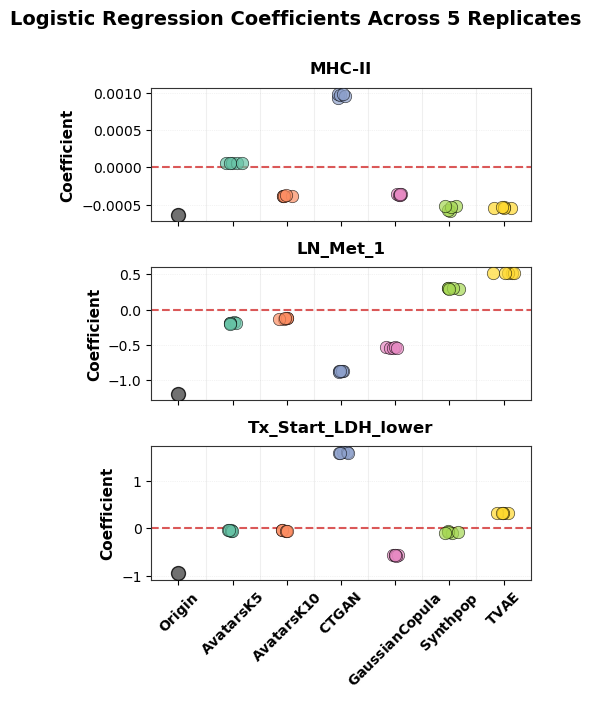

In [58]:
plot_coef_stripplot_3features(
    coef_by_seed=coef_by_seed,
    features=FEATURES_TO_PLOT,
    all_seeds=all_seeds,
    synthesizer_order=synthesizer_order,
    save_path='CoefViolin/Coeff_5_rep.pdf',
    figsize=(5,7),
)